In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os 

In [2]:
df = pd.read_csv('processed_student_data.csv')

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

print("Dataset shape:", df.shape)
print("Features:", X.shape[1])
print("Target range:", y.min(), "to", y.max())

Dataset shape: (6607, 35)
Features: 34
Target range: 55 to 101


In [3]:
# First split off 30% for val+test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Split that 30% evenly into val and test (15/15)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4624
Validation size: 991
Test size: 992


In [4]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
}

gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_.round(4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV MAE: 0.7919


In [5]:
results = pd.DataFrame(grid_search.cv_results_)
results['mean_test_score'] = -results['mean_test_score']

table = results[['param_n_estimators', 'param_learning_rate', 
                  'param_max_depth', 'mean_test_score', 'std_test_score']]
table.columns = ['n_estimators', 'learning_rate', 'max_depth', 'MAE (mean)', 'MAE (std)']
table = table.sort_values('MAE (mean)').head(10)

print(table.to_string(index=False))

 n_estimators  learning_rate  max_depth  MAE (mean)  MAE (std)
          300           0.05          3    0.791941   0.080041
          200           0.10          3    0.793718   0.081410
          300           0.10          3    0.814051   0.077346
          100           0.20          3    0.821586   0.077140
          200           0.05          3    0.862581   0.078539
          100           0.10          3    0.863721   0.081791
          200           0.20          3    0.865736   0.077527
          200           0.05          5    0.902400   0.084714
          300           0.05          5    0.904855   0.080426
          300           0.20          3    0.908325   0.067658


In [6]:
best_model = grid_search.best_estimator_

# Validate on validation set
val_preds = best_model.predict(X_val)
val_mae  = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_r2   = r2_score(y_val, val_preds)

print("--- Validation Set Performance ---")
print(f"MAE:  {val_mae:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²:   {val_r2:.4f}")

--- Validation Set Performance ---
MAE:  0.6791
RMSE: 1.7748
R²:   0.7469


In [7]:
test_preds = best_model.predict(X_test)
test_mae  = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2   = r2_score(y_test, test_preds)

print("--- Test Set Performance ---")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")

--- Test Set Performance ---
MAE:  0.7116
RMSE: 1.9805
R²:   0.7386


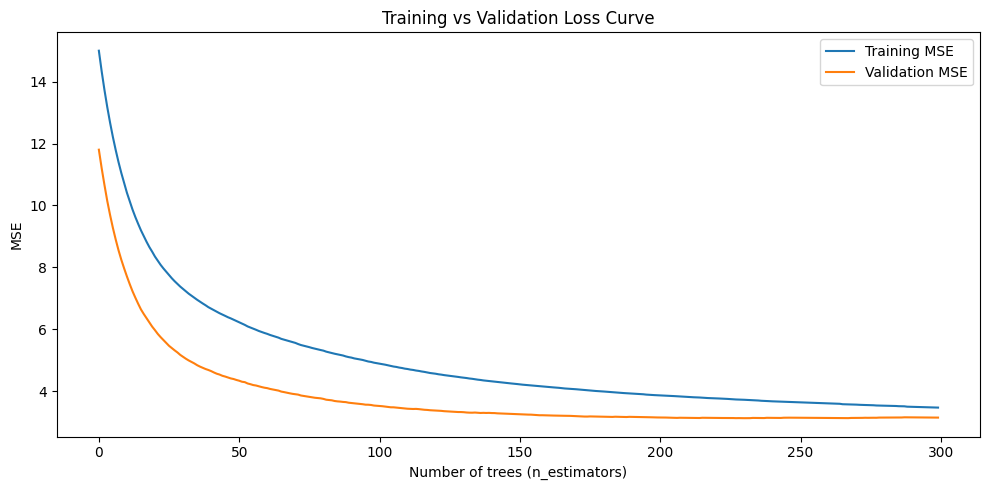

Saved: loss_curve.png


In [8]:
train_scores = []
val_scores   = []

# GBR exposes staged predictions — use these for the loss curve
for preds in best_model.staged_predict(X_train):
    train_scores.append(mean_squared_error(y_train, preds))

for preds in best_model.staged_predict(X_val):
    val_scores.append(mean_squared_error(y_val, preds))

plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training MSE')
plt.plot(val_scores,   label='Validation MSE')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Saved: loss_curve.png")

In [11]:

joblib.dump(best_model, 'student_performance_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Model saved: student_performance_model.pkl")
print("Feature names saved: feature_names.pkl")
print("Model size:", round(os.path.getsize('student_performance_model.pkl') / 1024, 1), "KB")

Model saved: student_performance_model.pkl
Feature names saved: feature_names.pkl
Model size: 393.7 KB
